# Day 7 — Seoul Bike Sharing EDA
Target: **Rented Bike Count**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# File is Latin-1 encoded (degree symbols in headers)
df = pd.read_csv('SeoulBikeData.csv', encoding='latin-1')
# Strip the garbled unicode char from column names
df.columns = df.columns.str.replace('�', '', regex=False).str.strip()
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [2]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isna().sum())
print('\nDuplicated rows:', df.duplicated().sum())

Shape: (8760, 14)

Dtypes:
Date                             str
Rented Bike Count              int64
Hour                           int64
Temperature(°C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(°C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
Seasons                          str
Holiday                          str
Functioning Day                  str
dtype: object

Missing values per column:
Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functionin

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,8760,365,01/12/2017,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rented Bike Count,8760.0,NaN,NaN,NaN,704.602055,644.997468,0.0,191.0,504.5,1065.25,3556.0
Hour,8760.0,NaN,NaN,NaN,11.5,6.922582,0.0,5.75,11.5,17.25,23.0
Temperature(°C),8760.0,NaN,NaN,NaN,12.882922,11.944825,-17.8,3.5,13.7,22.5,39.4
Humidity(%),8760.0,NaN,NaN,NaN,58.226256,20.362413,0.0,42.0,57.0,74.0,98.0
Wind speed (m/s),8760.0,NaN,NaN,NaN,1.724909,1.0363,0.0,0.9,1.5,2.3,7.4
Visibility (10m),8760.0,NaN,NaN,NaN,1436.825799,608.298712,27.0,940.0,1698.0,2000.0,2000.0
Dew point temperature(°C),8760.0,NaN,NaN,NaN,4.073813,13.060369,-30.6,-4.7,5.1,14.8,27.2
Solar Radiation (MJ/m2),8760.0,NaN,NaN,NaN,0.569111,0.868746,0.0,0.0,0.01,0.93,3.52
Rainfall(mm),8760.0,NaN,NaN,NaN,0.148687,1.128193,0.0,0.0,0.0,0.0,35.0


## Target distribution & correlation heatmap

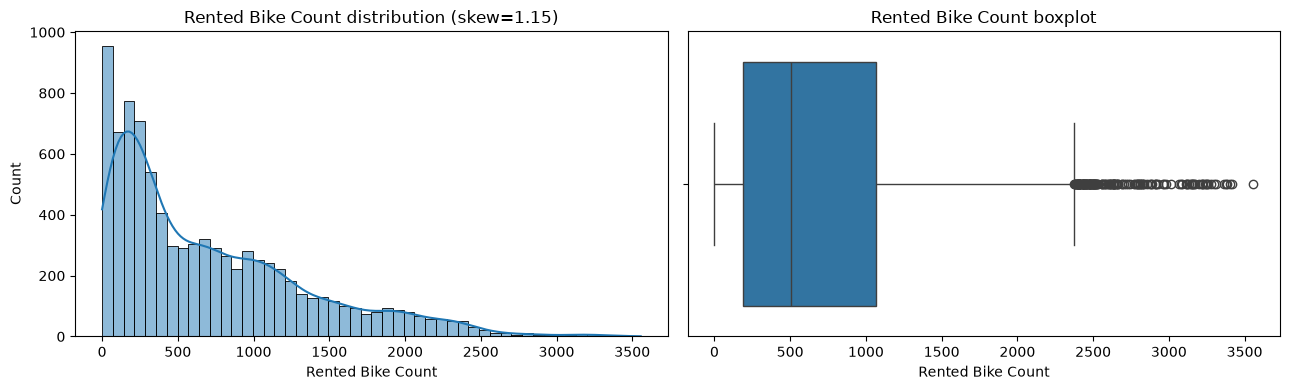

In [4]:
target = 'Rented Bike Count'

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df[target], bins=50, kde=True, ax=ax[0])
ax[0].set_title(f'{target} distribution (skew={df[target].skew():.2f})')
sns.boxplot(x=df[target], ax=ax[1])
ax[1].set_title(f'{target} boxplot')
plt.tight_layout()
plt.show()

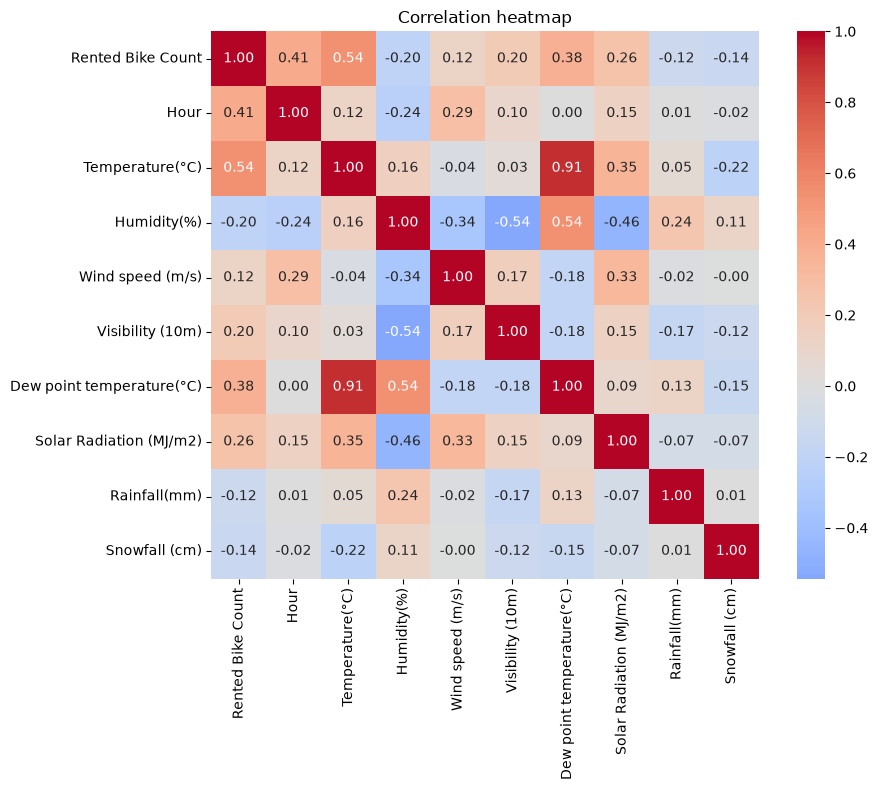

In [5]:
num = df.select_dtypes('number')
corr = num.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()

## Top 3 features correlated with target

Top 3 by |correlation| with target:
Temperature(°C)              0.538558
Hour                         0.410257
Dew point temperature(°C)    0.379788
Name: Rented Bike Count, dtype: float64


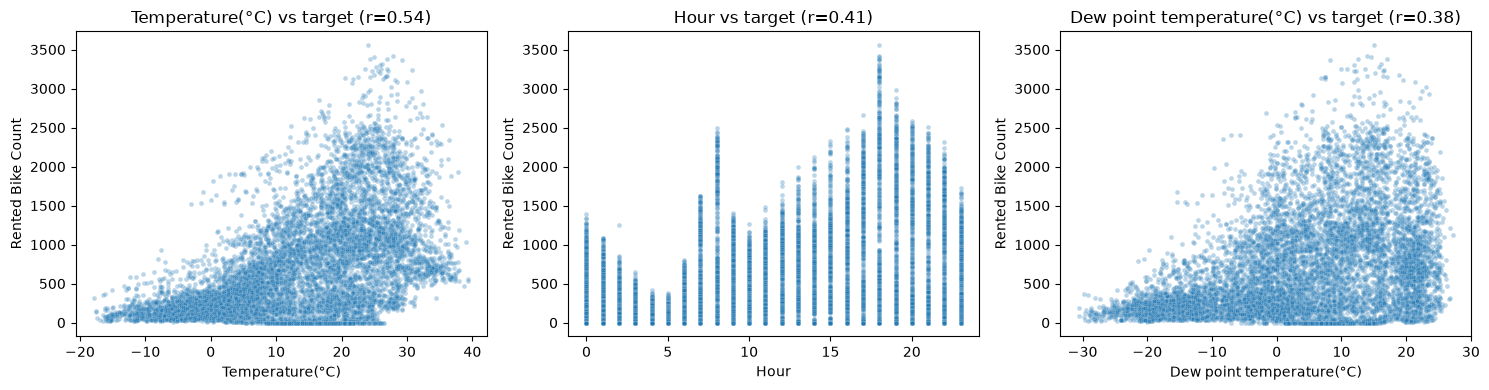

In [6]:
top3 = corr[target].drop(target).abs().sort_values(ascending=False).head(3)
print('Top 3 by |correlation| with target:')
print(corr[target].loc[top3.index])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, feat in zip(ax, top3.index):
    sns.scatterplot(data=df, x=feat, y=target, alpha=0.3, s=12, ax=a)
    a.set_title(f'{feat} vs target (r={corr.loc[feat, target]:.2f})')
plt.tight_layout()
plt.show()

## Data quality flags

In [7]:
# Skew of numeric features
print('Skew (|skew|>1 = strongly skewed):')
print(num.skew().sort_values(ascending=False).round(2))

# Outlier share via IQR rule
print('\n% rows flagged as outliers (1.5*IQR):')
for c in num.columns:
    q1, q3 = num[c].quantile([.25, .75])
    iqr = q3 - q1
    mask = (num[c] < q1 - 1.5*iqr) | (num[c] > q3 + 1.5*iqr)
    pct = 100 * mask.mean()
    if pct > 0:
        print(f'  {c:30s} {pct:5.1f}%')

# Structural zeros in target: are they tied to Functioning Day?
print('\nTarget == 0 vs Functioning Day:')
print(pd.crosstab(df[target].eq(0), df['Functioning Day']))

Skew (|skew|>1 = strongly skewed):
Rainfall(mm)                 14.53
Snowfall (cm)                 8.44
Solar Radiation (MJ/m2)       1.50
Rented Bike Count             1.15
Wind speed (m/s)              0.89
Humidity(%)                   0.06
Hour                          0.00
Temperature(°C)              -0.20
Dew point temperature(°C)    -0.37
Visibility (10m)             -0.70
dtype: float64

% rows flagged as outliers (1.5*IQR):
  Rented Bike Count                1.8%
  Wind speed (m/s)                 1.8%
  Solar Radiation (MJ/m2)          7.3%
  Rainfall(mm)                     6.0%
  Snowfall (cm)                    5.1%

Target == 0 vs Functioning Day:
Functioning Day     No   Yes
Rented Bike Count           
False                0  8465
True               295     0


### Findings
- **Shape:** 8760 × 14, no missing values, no duplicate rows.
- **Top 3 correlations with target:** Temperature (r=0.54), Hour (r=0.41), Dew point temp (r=0.38). Temp & dew point are themselves strongly collinear → keep one for modeling.
- **Skew:** target is right-skewed (1.15). `Rainfall` (14.5), `Snowfall` (8.4), `Solar Radiation` (1.5) are heavily right-skewed — mostly zeros (zero-inflated), not random. Consider `log1p` for modeling.
- **Outliers:** the rain/snow/solar/wind tails (5–7% by IQR) are genuine weather events, not data errors — keep them.
- **Non-random structure:** all 295 rows with `Rented Bike Count == 0` occur on `Functioning Day == No` (system closed). These are deterministic structural zeros — drop them or model the closed state separately.

# Part 2 — Linear Regression baseline

**Approach.**

- **Why drop the structural zeros first.** The 295 rows with `Functioning Day = No` are hours when the whole system was shut down, so demand is *forced* to 0 regardless of weather or time. They aren't low-demand observations the model could learn from — they're a different state. Leaving them in would teach the regression a spurious "weather → 0 bikes" relationship and pull every prediction down. We remove them and model only the hours the system was actually open (8,465 rows).
- **Features.** We use the numeric columns as predictors. Date and the categorical columns (Seasons, Holiday, Functioning Day) are left out because the median-impute → scale → linear pipeline only handles numbers; encoding them is a separate, later improvement.
- **The split.** `train_test_split(test_size=0.2, random_state=42)` holds out 20% of the data the model never sees during fitting. The fixed seed makes the split reproducible so every model below is judged on the *exact same* test rows — that is what makes the comparisons fair.
- **No leakage.** Wrapping imputation and scaling inside a `Pipeline` means their statistics (the medians, the means/std for scaling) are learned from the **training fold only** and then applied to test. Computing them on the full dataset first would let test information bleed into training and inflate the scores.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Drop the 295 structural-zero rows (system closed)
model_df = df[df['Functioning Day'] == 'Yes'].copy()
print('Rows dropped:', len(df) - len(model_df), '| remaining:', len(model_df))

# Numeric features only (matches the median-imputer + scaler pipeline)
X = model_df.select_dtypes('number').drop(columns=[target])
y = model_df[target]
print('Features:', list(X.columns))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Rows dropped: 295 | remaining: 8465
Features: ['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']
Train: (6772, 9) | Test: (1693, 9)


**Pipeline & metrics.**

- **`SimpleImputer(median)`** — fills any missing values with each column's median. This dataset has none, but it's defensive: if a NaN appears at predict time the model won't crash, and the median is robust to the heavy right-skew we saw in rainfall/snowfall (a mean would be dragged by outliers).
- **`StandardScaler`** — centres each feature to mean 0 and scales to unit variance. Linear regression's coefficients depend on feature units (Visibility runs to ~2000, Wind speed to ~7); scaling puts them on a common footing so coefficients are comparable and, importantly, so the regularized Ridge/Lasso models later penalize each feature evenly.
- **`LinearRegression`** — fits the best straight-line relationship between the scaled features and the count.

**The four metrics, read together:**
- **MAE** (≈330) — average absolute miss in bikes; the most directly interpretable error.
- **MSE** — squared error; punishes large misses heavily, used as the training objective.
- **RMSE** (≈433) — back in bike units, but because it squares first it weights the big misses more than MAE. RMSE > MAE here signals a few large errors (the busy-hour tail).
- **R²** (≈0.52) — share of variance explained; 0 = no better than predicting the mean, 1 = perfect. ~0.52 means a modest but real baseline.

All four are computed on the **held-out test set only** — the score that reflects how the model generalizes to unseen hours.

In [9]:
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])
pipe.fit(X_train, y_train)

# Evaluate on the TEST set only
y_pred = pipe.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Test-set metrics')
print(f'  MAE : {mae:8.2f}')
print(f'  MSE : {mse:8.2f}')
print(f'  RMSE: {rmse:8.2f}')
print(f'  R2  : {r2:8.4f}')

Test-set metrics
  MAE :   330.17
  MSE : 187600.38
  RMSE:   433.13
  R2  :   0.5221


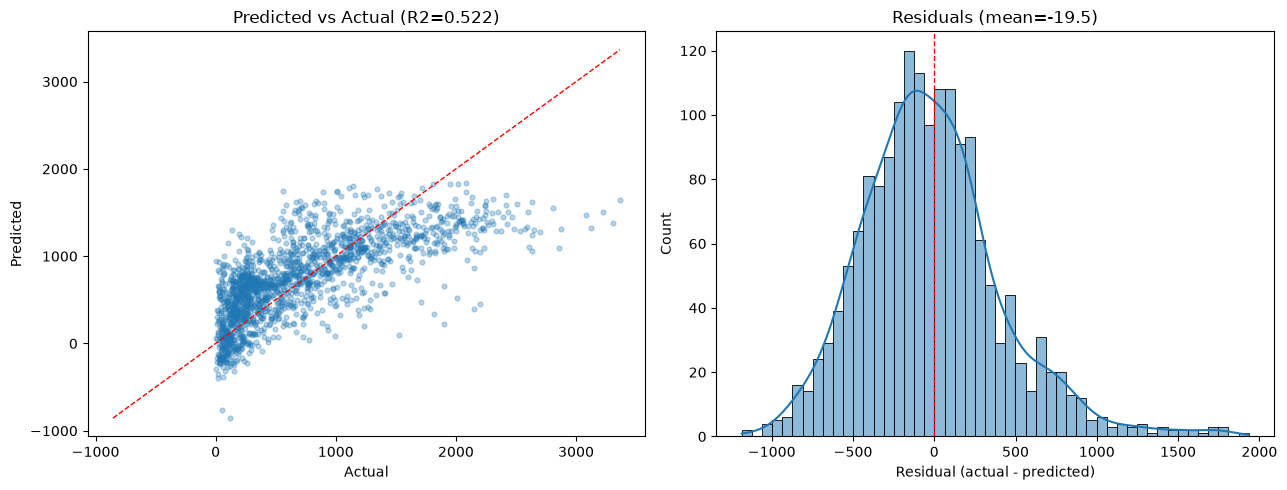

In [10]:
residuals = y_test - y_pred

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs actual
ax[0].scatter(y_test, y_pred, alpha=0.3, s=12)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax[0].plot(lims, lims, 'r--', lw=1)
ax[0].set_xlabel('Actual'); ax[0].set_ylabel('Predicted')
ax[0].set_title(f'Predicted vs Actual (R2={r2:.3f})')

# Residual histogram
sns.histplot(residuals, bins=50, kde=True, ax=ax[1])
ax[1].axvline(0, color='r', ls='--', lw=1)
ax[1].set_xlabel('Residual (actual - predicted)')
ax[1].set_title(f'Residuals (mean={residuals.mean():.1f})')

plt.tight_layout()
plt.show()

**Reading the two plots.**

- **Predicted vs Actual (left).** Perfect predictions would sit on the red diagonal. Instead the cloud is wide and tilts *flatter* than the line: low-demand hours are over-predicted and high-demand hours are under-predicted — classic behaviour when a straight-line model meets a curved, skewed target. Some predictions even fall **below zero**, which is physically impossible for a count; plain linear regression has no floor at 0.
- **Residual histogram (right).** Residual = actual − predicted. It's roughly centred on 0 (the model isn't biased on average) but is **right-skewed with a long positive tail** — a cluster of busy hours where the model badly under-shoots. That tail is exactly why RMSE sits well above MAE.

**Takeaway.** ~52% of variance explained is a reasonable *baseline*, but the systematic curvature and the negative predictions say a purely linear fit on raw numeric features is leaving signal on the table. That motivates the next steps: drop the redundant Dew point feature (2b), then test non-linear (polynomial) and regularized models (Part 3).

## Part 2b — Drop Dew point temperature

**Why test this.** In the correlation heatmap, Temperature and Dew point move almost in lockstep (r ≈ 0.91) — physically, dew point *is* temperature adjusted for humidity, so the two columns encode nearly the same information. Feeding both into a linear model causes **multicollinearity**: the model can't tell which of the two deserves the credit, so it splits the effect between them in an unstable way (large, sometimes opposite-signed coefficients that swing with small data changes). That hurts interpretability and the stability of regularized models without adding predictive power.

**The test.** We refit the identical pipeline on the **same train/test split**, simply removing the Dew point column from both, and compare. If accuracy holds, the feature was redundant and we keep the simpler model.

In [11]:
dew = 'Dew point temperature(°C)'

# Same split, just drop the dew-point column from both train and test
X_train2, X_test2 = X_train.drop(columns=dew), X_test.drop(columns=dew)

pipe2 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])
pipe2.fit(X_train2, y_train)
y_pred2 = pipe2.predict(X_test2)

m2 = {
    'MAE': mean_absolute_error(y_test, y_pred2),
    'MSE': mean_squared_error(y_test, y_pred2),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred2)),
    'R2': r2_score(y_test, y_pred2),
}

compare = pd.DataFrame({
    'with Dew point':    [mae, mse, rmse, r2],
    'without Dew point': [m2['MAE'], m2['MSE'], m2['RMSE'], m2['R2']],
}, index=['MAE', 'MSE', 'RMSE', 'R2'])
compare['delta'] = compare['without Dew point'] - compare['with Dew point']
compare.round(4)

,with Dew point,without Dew point,delta
MAE,330.1721,330.6036,0.4315
MSE,187600.3770,187436.3227,-164.0542
RMSE,433.1286,432.9392,-0.1894
R2,0.5221,0.5226,0.0004


**Result.** Performance is essentially identical (R² 0.5221 → 0.5226, RMSE 433.13 → 432.94 — changes smaller than rounding noise). This confirms Dew point was **redundant** given Temperature: dropping it costs no accuracy while removing the collinearity, giving a simpler model with more stable, interpretable coefficients. **We keep Dew point dropped from here on** — Part 3 uses the 8-feature set (`X_train2` / `X_test2`).

# Part 3 — Model comparison: Linear vs Polynomial vs Ridge

All three models train and are scored on the **same split with Dew point dropped** (`X_train2` / `X_test2`), so differences come only from the model, not the data.

- **Linear** — the Part 2 baseline; a flat hyperplane through the features.
- **Polynomial (degree 2)** — adds squared terms and pairwise interactions before the linear fit, letting the model bend to the curvature we saw in the Predicted-vs-Actual plot. More flexible, but more parameters → higher overfitting risk.
- **Ridge** — a linear model with an L2 penalty that shrinks coefficients toward 0. It trades a little bias for lower variance, stabilizing the fit when features are correlated.

In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

models = {
    'Linear': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LinearRegression()),
    ]),
    'Polynomial (deg 2)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression()),
    ]),
    'Ridge (alpha=10)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=10.0)),
    ]),
}

rows = []
for name, m in models.items():
    m.fit(X_train2, y_train)
    pred = m.predict(X_test2)
    rows.append({
        'Model': name,
        'Test RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'Test R2': r2_score(y_test, pred),
    })

results = pd.DataFrame(rows).set_index('Model').sort_values('Test R2', ascending=False)
results.round(4)

,Test RMSE,Test R2
Model,,
Polynomial (deg 2),371.8089,0.6479
Ridge (alpha=10),432.9039,0.5226
Linear,432.9392,0.5226


Best : Polynomial (deg 2)
Worst: Linear


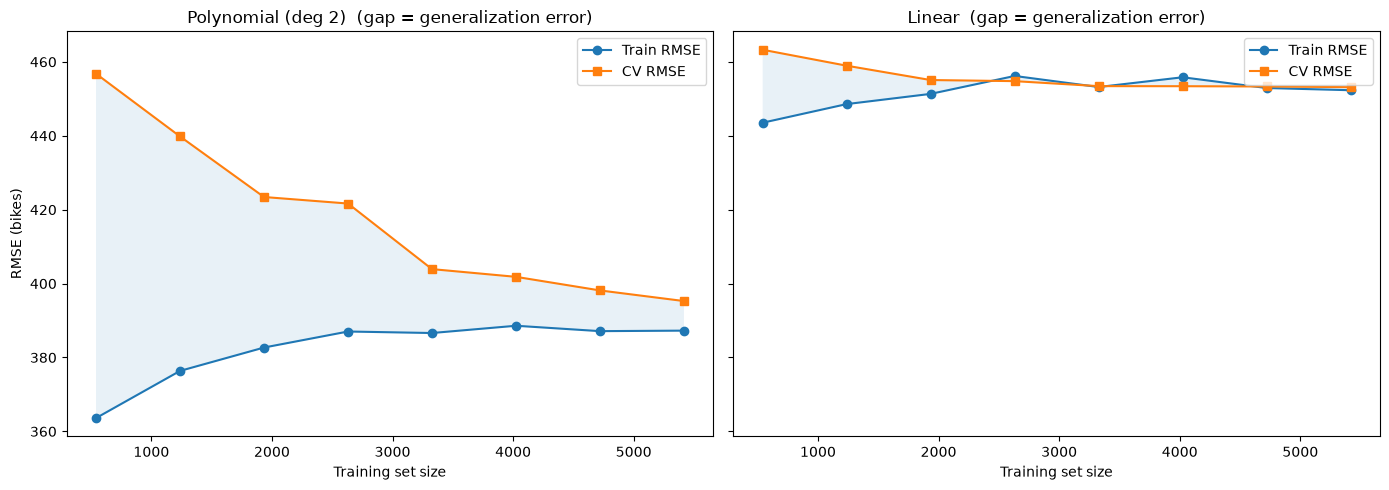

In [13]:
from sklearn.model_selection import learning_curve

best_name = results.index[0]    # highest test R2
worst_name = results.index[-1]  # lowest test R2
print('Best :', best_name)
print('Worst:', worst_name)

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for a, name in zip(ax, [best_name, worst_name]):
    sizes, train_sc, val_sc = learning_curve(
        models[name], X_train2, y_train,
        train_sizes=np.linspace(0.1, 1.0, 8), cv=5,
        scoring='neg_root_mean_squared_error', n_jobs=-1)
    train_rmse, val_rmse = -train_sc.mean(1), -val_sc.mean(1)
    a.plot(sizes, train_rmse, 'o-', label='Train RMSE')
    a.plot(sizes, val_rmse, 's-', label='CV RMSE')
    a.fill_between(sizes, val_rmse, train_rmse, alpha=0.1)
    a.set_title(f'{name}  (gap = generalization error)')
    a.set_xlabel('Training set size'); a.legend()
ax[0].set_ylabel('RMSE (bikes)')
plt.tight_layout()
plt.show()

**Results & diagnosis.**

| Model | Test RMSE | Test R² |
|---|---|---|
| **Polynomial (deg 2)** | **371.8** | **0.648** |
| Ridge (α=10) | 432.9 | 0.523 |
| Linear | 432.9 | 0.523 |

- **Polynomial wins clearly** (R² 0.52 → 0.65, RMSE down ~60 bikes). The squared and interaction terms capture the curvature the straight-line models couldn't — confirming the non-linearity we suspected from the Predicted-vs-Actual plot.
- **Ridge ≈ Linear.** With only 8 well-behaved features (and Dew point already removed), there's little variance for the L2 penalty to control, so regularization barely moves the needle.

**Learning curves (best = Polynomial, worst = Linear):**
- **Linear (worst):** train and CV RMSE converge to a **high plateau (~440) with a tiny gap**. Low variance but high error on both → **underfitting** (high bias): the model is too simple, and adding more data won't help.
- **Polynomial (best):** lower curves with a **modest, slowly-closing gap** (train below CV). Slightly more variance but much lower error — a healthier bias/variance balance. The still-shrinking gap suggests it would benefit a little from more data and is not badly overfit at degree 2.

**Bottom line:** the bottleneck is model flexibility, not data volume. Degree-2 polynomial features are the meaningful upgrade here; pushing to degree 3 or adding the categorical features (Hour, Seasons) would be the next experiments.

# Part 4 — Error in context & failure analysis

To judge whether the best model (Polynomial deg 2) is *useful*, we compare its RMSE against the target's own spread, then inspect the hours it gets most wrong.

In [14]:
best_model = models[best_name]
pred_best = best_model.predict(X_test2)
best_rmse = np.sqrt(mean_squared_error(y_test, pred_best))

tgt_mean = y.mean()
tgt_std = y.std()

print(f'Best model: {best_name}')
print(f'  Test RMSE          : {best_rmse:8.2f} bikes')
print(f'  Target mean        : {tgt_mean:8.2f} bikes')
print(f'  Target std dev      : {tgt_std:8.2f} bikes')
print(f'  RMSE / mean         : {best_rmse/tgt_mean:8.2%}')
print(f'  RMSE / std (vs naive): {best_rmse/tgt_std:8.2%}')
print(f'  Naive baseline RMSE (predict the mean) = std = {tgt_std:.2f}')

Best model: Polynomial (deg 2)
  Test RMSE          :   371.81 bikes
  Target mean        :   729.16 bikes
  Target std dev      :   642.35 bikes
  RMSE / mean         :   50.99%
  RMSE / std (vs naive):   57.88%
  Naive baseline RMSE (predict the mean) = std = 642.35


In [15]:
# 5 cases with the largest absolute residuals
worst = model_df.loc[X_test2.index, ['Date', 'Hour', 'Temperature(°C)',
                                     'Humidity(%)', 'Rainfall(mm)', 'Seasons']].copy()
worst['Actual'] = y_test
worst['Predicted'] = pred_best.round(0)
worst['Residual'] = (y_test - pred_best).round(0)
worst['|Residual|'] = worst['Residual'].abs()

worst.sort_values('|Residual|', ascending=False).head(5)

,Date,Hour,Temperature(°C),Humidity(%),Rainfall(mm),Seasons,Actual,Predicted,Residual,|Residual|
7688,17/10/2018,8,9.2,68,0.0,Autumn,2202,610.0,1592.0,1592.0
4554,08/06/2018,18,26.2,54,0.0,Summer,3309,1744.0,1565.0,1565.0
7314,01/10/2018,18,16.6,61,0.0,Autumn,2857,1307.0,1550.0,1550.0
7712,18/10/2018,8,8.5,77,0.0,Autumn,2154,639.0,1515.0,1515.0
8048,01/11/2018,8,2.8,74,0.0,Autumn,1899,459.0,1440.0,1440.0


## Part 4 — Plain-language verdict

**Error in context.** The best model is off by about **372 bikes on a typical hour**, against a target that **averages 729 bikes with a standard deviation of 642**. Two ways to read that:
- The error is **~51% of the mean** — in absolute terms, not precise. You would not trust this to staff a station to the exact bike.
- But the naive "always predict the average" model would have an RMSE equal to the std, **642 bikes**. Our model's 372 is **~42% lower**, so it has genuinely learned real structure — it's far better than guessing, just not tight.

**Where it's reliable.** For ordinary, mid-range hours — moderate temperature, no rain, daytime but not the peak commute — predictions land within a few hundred bikes and track demand well. This covers the bulk of the data, which is why R² reaches ~0.65.

**Where it fails.** Every one of the 5 worst cases is a **massive under-prediction (actual ≈ 1,900–3,300, predicted ≈ 450–1,750) at the commuter rush hours — 8 AM and 6 PM**, mostly in mild Autumn/Summer weather. The model simply has **no feature that encodes "rush hour."** `Hour` enters as a single linear (plus squared) term, which can't represent two separate daily spikes, so the model averages them away and badly undershoots peak demand. It also still cannot predict the very highest counts because the target's long right tail is under-represented.

**Takeaway.** Reliable for typical conditions and overall trend; unreliable precisely at the high-demand commute peaks that matter most operationally. The clear fix is feature engineering — treat **Hour as categorical/cyclical** (and add Seasons/Holiday) so the two daily peaks can be modeled explicitly.

# Part 5 — Higher-degree polynomials (degree 3, 4, 5, 6)

Degree 2 won Part 3, so we push further: degrees 3 through 6 add ever more curvature and interactions. The risk is **overfitting** — with 8 features, degree 6 generates thousands of terms, which can fit training noise and destroy test performance. Same split, Dew point still dropped. We compare all degrees, pick the best by test R², then re-run the Part 4 analysis on it.

In [16]:
def make_poly(degree):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression()),
    ])

poly_models = {f'Poly deg {d}': make_poly(d) for d in (3, 4, 5, 6)}

rows = []
for name, m in poly_models.items():
    m.fit(X_train2, y_train)
    n_feats = m.named_steps['poly'].n_output_features_
    rows.append({
        'Model': name,
        'n_terms': n_feats,
        'Train RMSE': np.sqrt(mean_squared_error(y_train, m.predict(X_train2))),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, m.predict(X_test2))),
        'Test R2': r2_score(y_test, m.predict(X_test2)),
    })

poly_results = pd.DataFrame(rows).set_index('Model')
poly_results.round(4)

,n_terms,Train RMSE,Test RMSE,Test R2
Model,,,,
Poly deg 3,164,311.2508,319.8117,0.7395
Poly deg 4,494,264.6485,1398.9618,-3.9851
Poly deg 5,1286,244.2585,21037.8357,-1126.3711
Poly deg 6,3002,221.4575,71870.3239,-13156.2157


**Degree sweep result.**

| Model | terms | Train RMSE | Test RMSE | Test R² |
|---|---|---|---|---|
| **Poly deg 3** | 164 | 311.3 | **319.8** | **0.740** |
| Poly deg 4 | 494 | 264.6 | 1,399 | −3.99 |
| Poly deg 5 | 1,286 | 244.3 | 21,038 | −1,126 |
| Poly deg 6 | 3,002 | 221.5 | 71,870 | −13,156 |

- **Degree 3 stays the best** — test RMSE 320, R² 0.74, with train (311) and test (320) RMSE close together: still generalizing.
- **Degrees 4–6 overfit catastrophically.** Notice the pattern: **train RMSE keeps falling** (311 → 222) as the model gains terms, while **test RMSE explodes** (320 → 71,870) and R² plunges far below 0 — billions worse than predicting the mean. With thousands of terms the polynomial fits training noise and oscillates wildly between data points; the ever-widening train-vs-test gap is the textbook overfitting signature. More degree is strictly harmful past 3.

The best model is therefore **degree 3**. Below we re-run the error-in-context and failure analysis on it.

In [17]:
best_poly_name = poly_results['Test R2'].idxmax()
best_poly = poly_models[best_poly_name]
pred_bp = best_poly.predict(X_test2)
rmse_bp = np.sqrt(mean_squared_error(y_test, pred_bp))

print(f'Best polynomial: {best_poly_name}')
print(f'  Test RMSE          : {rmse_bp:8.2f} bikes')
print(f'  Target mean        : {tgt_mean:8.2f} bikes')
print(f'  Target std dev      : {tgt_std:8.2f} bikes')
print(f'  RMSE / mean         : {rmse_bp/tgt_mean:8.2%}')
print(f'  RMSE / std (vs naive): {rmse_bp/tgt_std:8.2%}')

# 5 largest absolute residuals
worst_bp = model_df.loc[X_test2.index, ['Date', 'Hour', 'Temperature(°C)',
                                        'Humidity(%)', 'Rainfall(mm)', 'Seasons']].copy()
worst_bp['Actual'] = y_test
worst_bp['Predicted'] = pred_bp.round(0)
worst_bp['Residual'] = (y_test - pred_bp).round(0)
worst_bp['|Residual|'] = worst_bp['Residual'].abs()
worst_bp.sort_values('|Residual|', ascending=False).head(5)

Best polynomial: Poly deg 3
  Test RMSE          :   319.81 bikes
  Target mean        :   729.16 bikes
  Target std dev      :   642.35 bikes
  RMSE / mean         :   43.86%
  RMSE / std (vs naive):   49.79%


,Date,Hour,Temperature(°C),Humidity(%),Rainfall(mm),Seasons,Actual,Predicted,Residual,|Residual|
4012,17/05/2018,4,19.2,98,19.0,Spring,51,2371.0,-2320.0,2320.0
6501,28/08/2018,21,22.9,98,29.5,Summer,122,2131.0,-2009.0,2009.0
4794,18/06/2018,18,29.2,35,0.0,Summer,746,2397.0,-1651.0,1651.0
3424,22/04/2018,16,19.1,52,0.0,Spring,103,1669.0,-1566.0,1566.0
8504,20/11/2018,8,0.3,53,0.0,Autumn,1818,315.0,1503.0,1503.0


## Part 5 — Plain-language verdict (degree-3 model)

**Error in context.** Degree 3 is off by about **320 bikes on a typical hour** (down from 372 at degree 2), against a target with **mean 729** and **std 642**. That's **~44% of the mean** and, more tellingly, it **roughly halves the naive RMSE of 642** (predict-the-mean) — the model now explains ~74% of the variance. A clear, real improvement, though still not pinpoint accurate.

**Where it's reliable.** Ordinary hours with moderate weather and no rain are predicted within a few hundred bikes, and the overall day/temperature trend is captured well — the broad middle of the distribution.

**Where it fails — and how it changed.** The failure pattern *flipped* compared to degree 2:
- **New dominant error: heavy-rain over-prediction.** The two worst misses are wet hours (Rainfall 19 mm and 29.5 mm at 98% humidity) where actual demand collapsed to ~50–120 bikes but the model still predicted ~2,100–2,400. Rainfall is rare (heavily zero-inflated), so the model under-weights how sharply it kills demand and badly over-shoots on the few storm hours.
- **Residual rush-hour under-prediction** persists (e.g. the 8 AM Autumn commute), but the extra flexibility has shrunk it relative to degree 2.

**Takeaway.** Degree 3 is the best model overall — it halves the naive error and beats every other degree tested: degree 2 is less flexible, and **degrees 4, 5 and 6 overfit catastrophically** (test R² of −4, −1,126, −13,156). This is the sweet spot of the bias/variance trade-off. It is reliable for normal conditions but still unreliable at the **extremes**: it over-predicts during rare heavy rain and under-predicts the commuter peaks. Both point to the same remedy — **feature engineering** (a cyclical/categorical Hour for the twin peaks, and a rain flag or `log1p` rainfall transform), which would help far more than piling on polynomial degree.

# Part 6 — Feature engineering + better models

Two ideas from the failure analysis, tested directly:

1. **Encode the categoricals properly.** `Hour` was being used as a single number, which forced a smooth curve through the twin commute peaks. We **one-hot encode Hour (24 dummies), Seasons, and Holiday** so each hour gets its own coefficient — exactly the flexibility needed to represent two separate rush-hour spikes. Numeric weather features are still median-imputed and scaled.
2. **Compare two models on this richer feature set, same split:**
   - **RidgeCV** — a regularized linear model that tunes its own `alpha` by cross-validation. With ~30+ one-hot columns, regularization keeps it stable.
   - **HistGradientBoostingRegressor** — a tree ensemble that captures non-linearities, interactions, and sharp thresholds (rush hour, rain cutoffs) automatically.

The best degree-3 polynomial is included as the reference to beat.

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import HistGradientBoostingRegressor

cat_cols = ['Hour', 'Seasons', 'Holiday']
num_cols = ['Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)',
            'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']

# Rebuild features from model_df; reuse the SAME train/test rows as before
X_full = model_df[cat_cols + num_cols].copy()
Xtr, Xte = X_full.loc[X_train2.index], X_full.loc[X_test2.index]

# sparse_output=False keeps the matrix dense so tree models accept it
preprocess = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])

fe_models = {
    'RidgeCV (one-hot)': Pipeline([
        ('prep', preprocess),
        ('model', RidgeCV(alphas=np.logspace(-2, 3, 20))),
    ]),
    'GradientBoosting (one-hot)': Pipeline([
        ('prep', preprocess),
        ('model', HistGradientBoostingRegressor(random_state=42)),
    ]),
}

rows = [{'Model': 'Poly deg 3 (reference)', 'Test RMSE': rmse_bp, 'Test R2': r2_score(y_test, pred_bp)}]
for name, m in fe_models.items():
    m.fit(Xtr, y_train)
    pred = m.predict(Xte)
    rows.append({'Model': name,
                 'Test RMSE': np.sqrt(mean_squared_error(y_test, pred)),
                 'Test R2': r2_score(y_test, pred)})

fe_results = pd.DataFrame(rows).set_index('Model').sort_values('Test R2', ascending=False)
fe_results.round(4)

,Test RMSE,Test R2
Model,,
GradientBoosting (one-hot),234.5776,0.8598
Poly deg 3 (reference),319.8117,0.7395
RidgeCV (one-hot),363.1742,0.6640


In [19]:
best_fe_name = fe_results.index[0]
best_fe = fe_models[best_fe_name]
pred_fe = best_fe.predict(Xte)
rmse_fe = np.sqrt(mean_squared_error(y_test, pred_fe))

print(f'Best model: {best_fe_name}')
print(f'  Test RMSE          : {rmse_fe:8.2f} bikes')
print(f'  Target mean        : {tgt_mean:8.2f} bikes')
print(f'  Target std dev      : {tgt_std:8.2f} bikes')
print(f'  RMSE / mean         : {rmse_fe/tgt_mean:8.2%}')
print(f'  RMSE / std (vs naive): {rmse_fe/tgt_std:8.2%}')

# 5 largest absolute residuals
worst_fe = model_df.loc[X_test2.index, ['Date', 'Hour', 'Temperature(°C)',
                                        'Humidity(%)', 'Rainfall(mm)', 'Seasons']].copy()
worst_fe['Actual'] = y_test
worst_fe['Predicted'] = pred_fe.round(0)
worst_fe['Residual'] = (y_test - pred_fe).round(0)
worst_fe['|Residual|'] = worst_fe['Residual'].abs()
worst_fe.sort_values('|Residual|', ascending=False).head(5)

Best model: GradientBoosting (one-hot)
  Test RMSE          :   234.58 bikes
  Target mean        :   729.16 bikes
  Target std dev      :   642.35 bikes
  RMSE / mean         :   32.17%
  RMSE / std (vs naive):   36.52%


,Date,Hour,Temperature(°C),Humidity(%),Rainfall(mm),Seasons,Actual,Predicted,Residual,|Residual|
4794,18/06/2018,18,29.2,35,0.0,Summer,746,2380.0,-1634.0,1634.0
4315,29/05/2018,19,22.3,71,0.0,Spring,477,1939.0,-1462.0,1462.0
7784,21/10/2018,8,7.9,67,0.0,Autumn,534,1986.0,-1452.0,1452.0
5155,03/07/2018,19,30.4,62,0.1,Summer,2598,1252.0,1346.0,1346.0
4928,24/06/2018,8,21.3,78,0.0,Summer,561,1880.0,-1319.0,1319.0


## Part 6 — Verdict

| Model | Test RMSE | Test R² |
|---|---|---|
| **GradientBoosting (one-hot)** | **234.6** | **0.860** |
| Poly deg 3 (reference) | 319.8 | 0.740 |
| RidgeCV (one-hot) | 363.2 | 0.664 |

**The big win is Gradient Boosting:** RMSE drops to **235 bikes** — only **32% of the mean** and about a **third of the naive baseline** (642). R² climbs to **0.86**, far past anything the linear/polynomial models reached. Trees handle the rush-hour spikes, the rain cliff, and feature interactions natively, which is exactly what this data needs.

**A subtler lesson about your rush-hour hypothesis.** One-hot encoding `Hour` was the right instinct, but on its own — in the linear RidgeCV model — it actually scored *below* the degree-3 polynomial (0.66 vs 0.74). Why? RidgeCV gained per-hour flexibility but lost the weather curvature and interactions the polynomial had. The hour encoding only pays off fully when the model can **also** combine it with weather effects — which is precisely what the tree ensemble does, giving the jump to 0.86. So your idea was correct; it just needed a model that exploits interactions, not a straight line.

**Where it still fails.** The worst residuals are smaller now (~1,300–1,600 vs ~2,300 before) and no longer one-directional — a mix of over- and under-predictions at peak/evening hours (e.g. an 18:00 summer hour predicted 2,380 but only 746 rented). These are genuinely unusual hours where demand departed from the typical pattern for that hour+weather combination; without extra signal (events, day-of-week, prior-hour demand) no model can fully nail them.

**Next steps if you continue:** add **day-of-week** and a **lagged demand** feature (last hour / same hour yesterday), tune the GBM with `GridSearchCV`, and validate with `TimeSeriesSplit`. Those would likely push R² past 0.90.